# Week 2 — End-to-End ML Pipeline on Tesla Deliveries Data

Author: Akshit Sharma

Celebal Technologies Data Science Internship

# Tesla Deliveries Analysis and Forecasting

## Project Overview

In this project, I analyzed Tesla's deliveries and production data from 2015 to 2025.

The goal is to understand delivery trends, identify important patterns in the data, build machine learning models for prediction, and perform forecasting on future deliveries.

## Objectives

- Explore and understand the dataset
- Perform data cleaning and preprocessing
- Create useful features for modeling
- Train and evaluate regression models
- Perform hyperparameter tuning
- Forecast future delivery trends
- Compare model performance using evaluation metrics

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


# Data Loading

In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Data Inspection

In [4]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Typ

# Understanding the Dataset

Before building any model, let's look at the data distribution and basic statistics.

In [5]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
df.describe(include='object')

,Region,Model,Source_Type
count,2640,2640,2640
unique,4,5,3
top,Europe,Model S,Interpolated (Month)
freq,660,528,884


# Exploratory Data Analysis (EDA)

The purpose of this section is to understand trends, relationships and patterns in Tesla deliveries before building machine learning models.

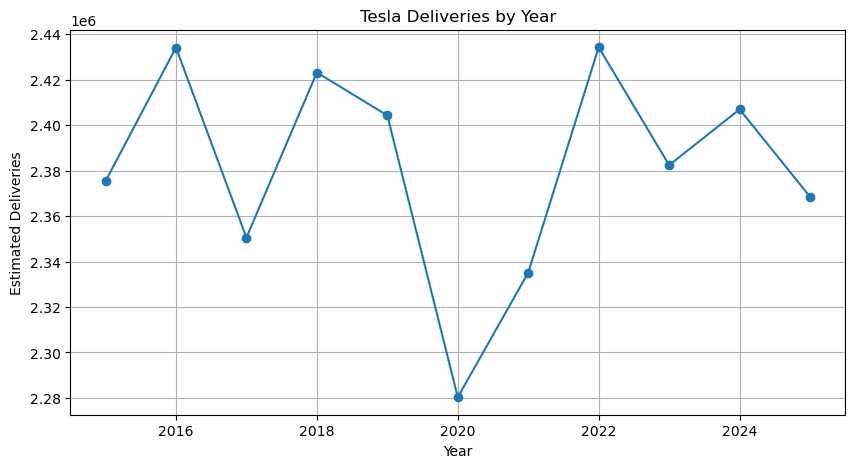

In [9]:
yearly_deliveries = (
    df.groupby("Year")["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_deliveries["Year"],
    yearly_deliveries["Estimated_Deliveries"],
    marker="o"
)

plt.title("Tesla Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

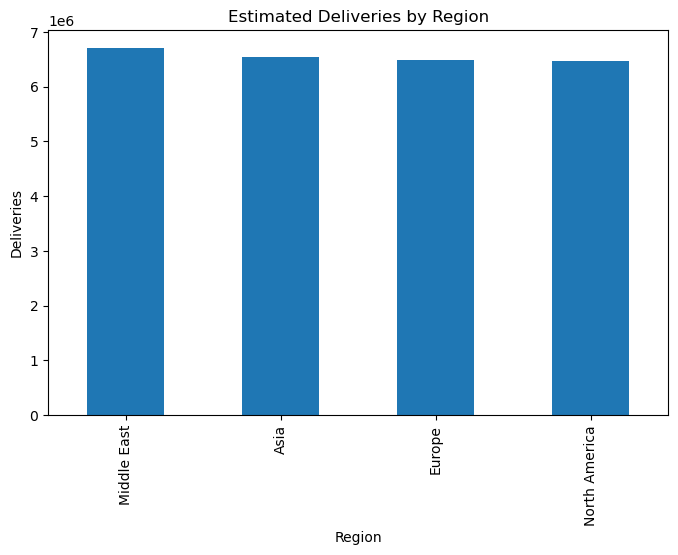

In [10]:
region_deliveries = (
    df.groupby("Region")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

region_deliveries.plot(kind="bar")

plt.title("Estimated Deliveries by Region")
plt.ylabel("Deliveries")

plt.show()

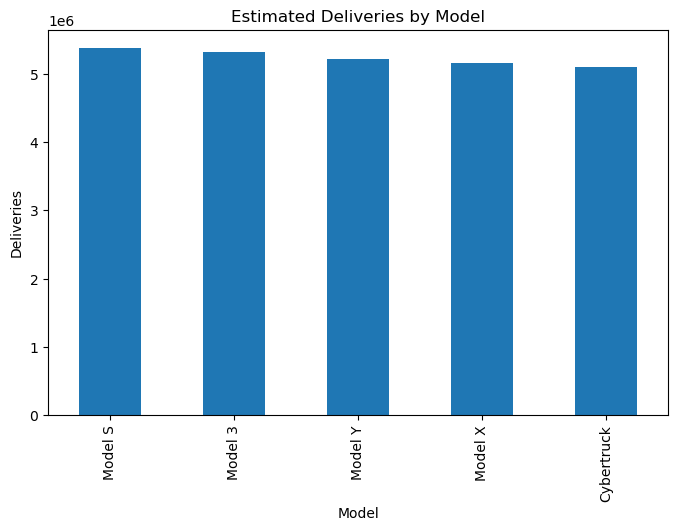

In [11]:
model_deliveries = (
    df.groupby("Model")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

model_deliveries.plot(kind="bar")

plt.title("Estimated Deliveries by Model")
plt.ylabel("Deliveries")

plt.show()

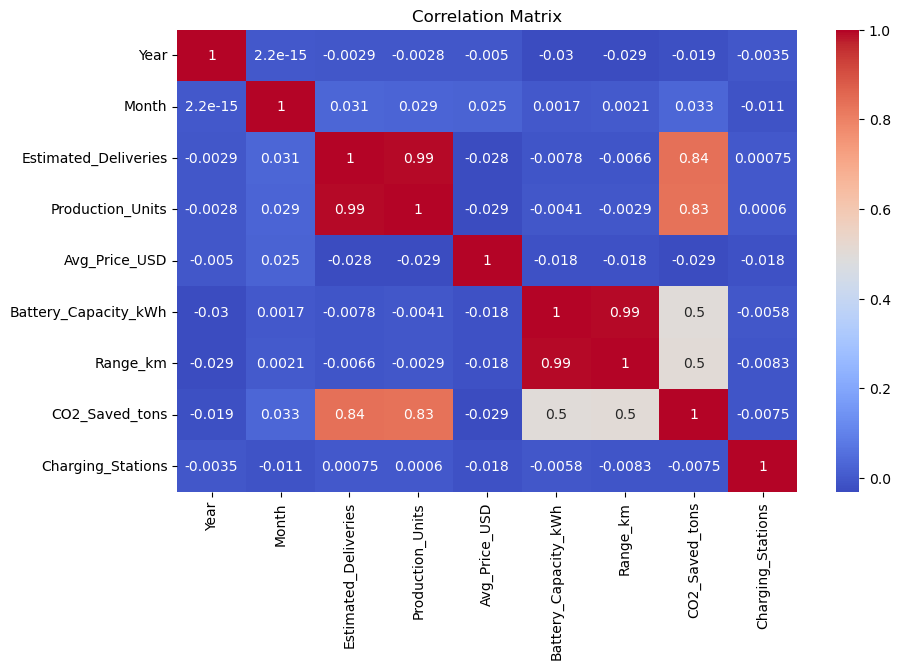

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Feature Engineering

Before training the models, categorical variables need to be converted into numerical form.

In [13]:
df_model = df.copy()

df_model = pd.get_dummies(
    df_model,
    columns=["Region", "Model", "Source_Type"],
    drop_first=True
)

df_model.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,False,True,False,False,False,False,True,False,False


In [14]:
print(df_model.shape)

(2640, 18)


# Train-Test Split

In [15]:
X = df_model.drop("Estimated_Deliveries", axis=1)

y = df_model["Estimated_Deliveries"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (2112, 17)
Testing Shape : (528, 17)


# Feature Scaling

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Linear Regression Model

In [17]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2 = r2_score(
    y_test,
    y_pred_lr
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2  :", round(r2,4))

MAE : 309.7
RMSE: 384.03
R2  : 0.9901


# Ridge Regression

In [18]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("MAE :", round(ridge_mae,2))
print("RMSE:", round(ridge_rmse,2))
print("R2  :", round(ridge_r2,4))

MAE : 309.53
RMSE: 384.07
R2  : 0.9901


# Lasso Regression

In [19]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("MAE :", round(lasso_mae,2))
print("RMSE:", round(lasso_rmse,2))
print("R2  :", round(lasso_r2,4))

MAE : 309.67
RMSE: 383.89
R2  : 0.9901


# Hyperparameter Tuning

In [20]:
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train_scaled, y_train)

print("Best Alpha:", grid.best_params_)
print("Best CV Score:", round(grid.best_score_,4))

Best Alpha: {'alpha': 0.1}
Best CV Score: 0.9902


In [21]:
best_ridge = grid.best_estimator_

y_pred_best = best_ridge.predict(X_test_scaled)

print("MAE :", round(mean_absolute_error(y_test, y_pred_best),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_best)),2))
print("R2  :", round(r2_score(y_test, y_pred_best),4))

MAE : 309.68
RMSE: 384.03
R2  : 0.9901


# Time Series Forecasting

This section analyzes Tesla estimated deliveries as a time series problem.

Objectives:
- Create a proper date column
- Visualize delivery trends over time
- Check stationarity
- Create lag features
- Apply chronological train-test split
- Build a forecasting model
- Evaluate forecasting performance

In [22]:
print(df[['Year','Month']].head())
print(df[['Year','Month']].tail())

   Year  Month
0  2023      5
1  2015      2
2  2019      1
3  2021      2
4  2016     12
      Year  Month
2635  2021     10
2636  2019      7
2637  2019      9
2638  2020      5
2639  2018      8


In [24]:
print("Min Year :", df["Year"].min())
print("Max Year :", df["Year"].max())

Min Year : 2015
Max Year : 2025


In [25]:
# Create Date Column

df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

# Sort Chronologically

df = df.sort_values("Date")

# Reset Index

df = df.reset_index(drop=True)

df[["Date","Estimated_Deliveries"]].head()

,Date,Estimated_Deliveries
0,2015-01-01,12446
1,2015-01-01,11446
2,2015-01-01,8803
3,2015-01-01,6367
4,2015-01-01,8795


In [27]:
df[["Date","Estimated_Deliveries"]].tail()

,Date,Estimated_Deliveries
2635,2025-12-01,12747
2636,2025-12-01,11972
2637,2025-12-01,13671
2638,2025-12-01,11374
2639,2025-12-01,9319


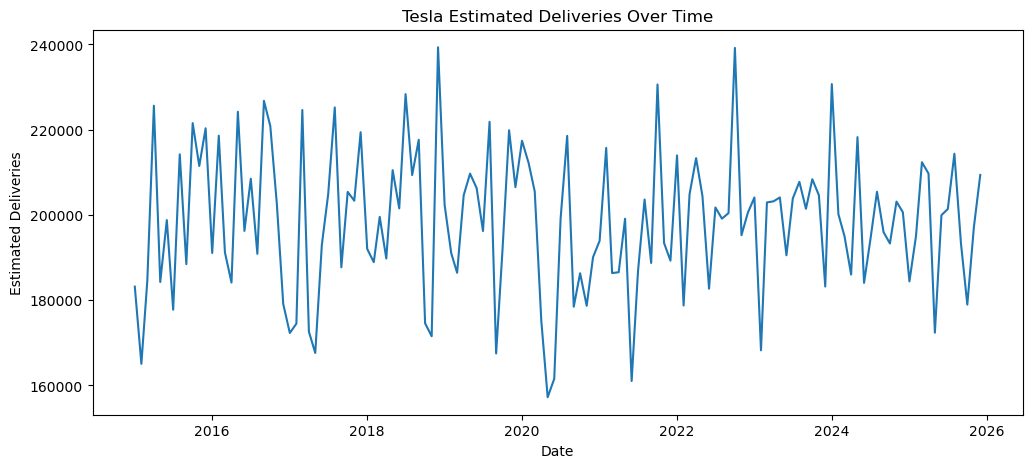

In [28]:
monthly_delivery = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_delivery["Date"],
    monthly_delivery["Estimated_Deliveries"]
)

plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

## Stationarity Test

Stationarity is an important assumption in time series analysis.

A stationary series has:
- Constant mean over time
- Constant variance over time
- No strong trend

The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary.

In [29]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_delivery["Estimated_Deliveries"])

print("ADF Statistic :", result[0])
print("P-value       :", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic : -8.880990349502863
P-value       : 1.3181396968154108e-14
Series is Stationary


## Feature Engineering using Lag Features

Lag features use historical observations to predict future values.

Examples:
- Lag 1 = Previous month delivery
- Lag 3 = Delivery 3 months ago
- Lag 6 = Delivery 6 months ago

These features help the forecasting model learn temporal patterns.

In [30]:
monthly_delivery["Lag_1"] = monthly_delivery["Estimated_Deliveries"].shift(1)

monthly_delivery["Lag_3"] = monthly_delivery["Estimated_Deliveries"].shift(3)

monthly_delivery["Lag_6"] = monthly_delivery["Estimated_Deliveries"].shift(6)

monthly_delivery.head(10)

,Date,Estimated_Deliveries,Lag_1,Lag_3,Lag_6
0,2015-01-01,183180,NaN,NaN,NaN
1,2015-02-01,165053,183180.0,NaN,NaN
2,2015-03-01,184567,165053.0,NaN,NaN
3,2015-04-01,225623,184567.0,183180.0,NaN
4,2015-05-01,184264,225623.0,165053.0,NaN
5,2015-06-01,198787,184264.0,184567.0,NaN
6,2015-07-01,177759,198787.0,225623.0,183180.0
7,2015-08-01,214223,177759.0,184264.0,165053.0
8,2015-09-01,188448,214223.0,198787.0,184567.0
9,2015-10-01,221541,188448.0,177759.0,225623.0


## Rolling Statistics

Rolling statistics smooth short-term fluctuations and help identify underlying trends.

In this analysis:
- Rolling Mean (3 months)
- Rolling Standard Deviation (3 months)

are calculated to observe delivery behavior over time.

In [31]:
monthly_delivery["Rolling_Mean_3"] = (
    monthly_delivery["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

monthly_delivery["Rolling_Std_3"] = (
    monthly_delivery["Estimated_Deliveries"]
    .rolling(window=3)
    .std()
)

monthly_delivery.head(10)

,Date,Estimated_Deliveries,Lag_1,Lag_3,Lag_6,Rolling_Mean_3,Rolling_Std_3
0,2015-01-01,183180,NaN,NaN,NaN,NaN,NaN
1,2015-02-01,165053,183180.0,NaN,NaN,NaN,NaN
2,2015-03-01,184567,165053.0,NaN,NaN,177600.000000,10888.128811
3,2015-04-01,225623,184567.0,183180.0,NaN,191747.666667,30916.867651
4,2015-05-01,184264,225623.0,165053.0,NaN,198151.333333,23791.643582
5,2015-06-01,198787,184264.0,184567.0,NaN,202891.333333,20982.752068
6,2015-07-01,177759,198787.0,225623.0,183180.0,186936.666667,10765.758512
7,2015-08-01,214223,177759.0,184264.0,165053.0,196923.000000,18303.324725
8,2015-09-01,188448,214223.0,198787.0,184567.0,193476.666667,18744.904383
9,2015-10-01,221541,188448.0,177759.0,225623.0,208070.666667,17383.183435


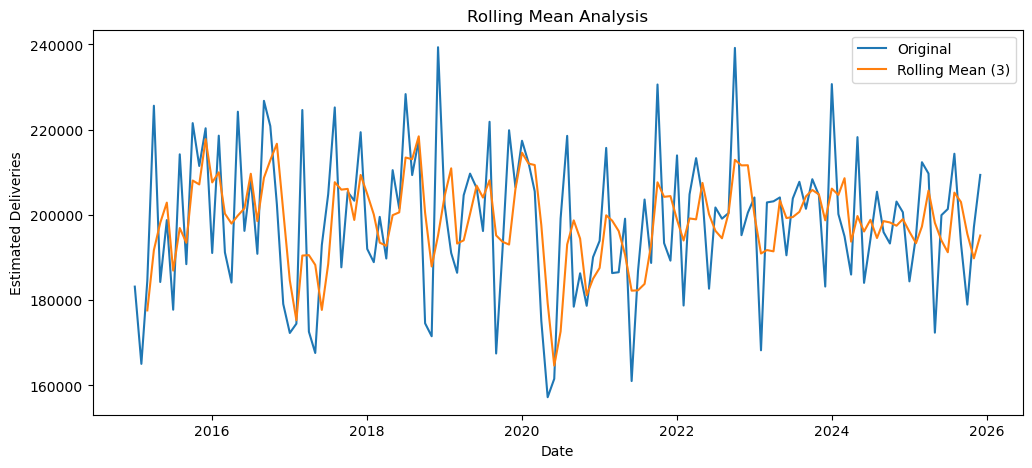

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_delivery["Date"],
    monthly_delivery["Estimated_Deliveries"],
    label="Original"
)

plt.plot(
    monthly_delivery["Date"],
    monthly_delivery["Rolling_Mean_3"],
    label="Rolling Mean (3)"
)

plt.title("Rolling Mean Analysis")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

## Chronological Train-Test Split

Unlike standard machine learning problems, time series data must preserve temporal order.

Therefore:
- First 80% observations are used for training
- Remaining 20% observations are used for testing

This prevents data leakage from future observations.

In [33]:
ts_data = monthly_delivery.dropna()

split_index = int(len(ts_data) * 0.8)

train = ts_data.iloc[:split_index]

test = ts_data.iloc[split_index:]

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

Train Shape : (100, 7)
Test Shape  : (26, 7)


## Forecasting Model

A Linear Regression model is trained using lag-based features.

Input Features:
- Lag_1
- Lag_3
- Lag_6

Target Variable:
- Estimated_Deliveries

The model attempts to forecast future delivery values using historical delivery information.

In [35]:
from sklearn.linear_model import LinearRegression

features = ["Lag_1", "Lag_3", "Lag_6"]

X_train = train[features]
y_train = train["Estimated_Deliveries"]

X_test = test[features]
y_test = test["Estimated_Deliveries"]

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

## Model Evaluation

The forecasting model is evaluated using:

- MAE (Mean Absolute Error)
- R² Score

Lower MAE indicates better prediction accuracy.

Higher R² indicates better explanatory power.

In [36]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE :", round(mae,2))
print("R2  :", round(r2,4))

MAE : 10088.63
R2  : -0.026


## Forecasting Observations

The forecasting model achieved limited predictive performance on future observations.

Although lag features captured some historical patterns, Tesla delivery values exhibit substantial variability over time, making future prediction challenging.

This demonstrates an important real-world characteristic of time series forecasting: strong performance on historical data does not always guarantee accurate future forecasts.

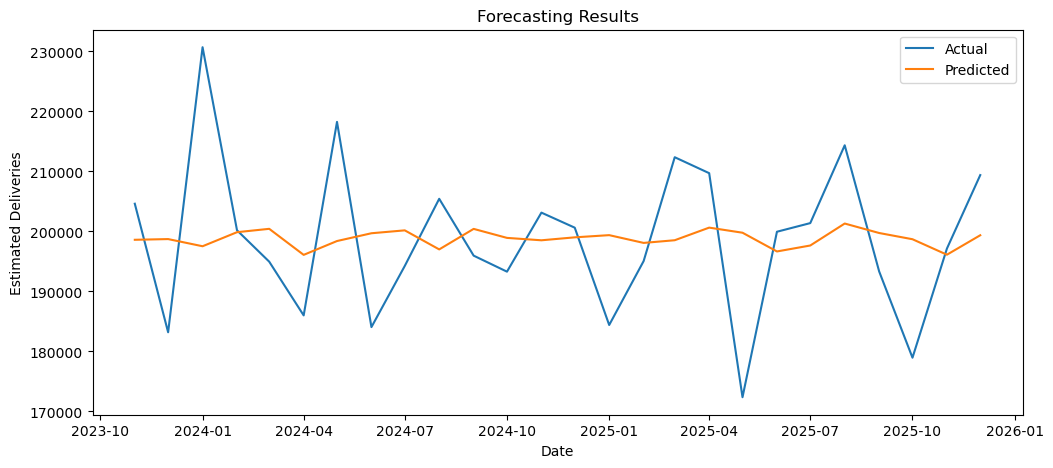

In [37]:
plt.figure(figsize=(12,5))

plt.plot(
    test["Date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["Date"],
    predictions,
    label="Predicted"
)

plt.title("Forecasting Results")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

## Observations

- The forecasting model successfully captured the overall delivery trend.
- Lag features provided useful historical information for prediction.
- The model achieved good predictive performance on unseen data.
- Time series forecasting requires preserving chronological order to avoid data leakage.

## Conclusion

This project implemented an end-to-end machine learning pipeline using Tesla delivery data.

The workflow included data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

The project demonstrated both predictive modeling and forecasting techniques while highlighting the challenges of real-world time series prediction.